<a href="https://colab.research.google.com/github/janetakhati-gif/Dancing/blob/main/WEB_SCRAPPING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Overview**

Web scraping is the process of extracting and processing large amounts of data from websites using algorithms or computer programs.

This practice is crucial for data scientists, engineers, or anyone involved in data analysis. Python is widely used for web scraping due to its ease of use and powerful libraries.

In this guide, we'll walk through the basics of web scraping and explore how to use Python libraries such as BeautifulSoup, Scrapy, and Selenium for web scraping.

**Why Python for Web Scraping?**

Python is one of the most popular languages for web scraping for several reasons:

**Rich Ecosystem:** Python has libraries like Numpy, Matplotlib, Pandas, BeautifulSoup, and Selenium that make web scraping and subsequent data manipulation easier.

**Ease of Use: **Python’s simple syntax and dynamic typing make it ideal for quick coding without boilerplate code.

**Compact Code:** Python allows you to write small, effective scripts to scrape large amounts of data without excessive code.

**Readability:** Python code is easy to read and maintain, which is crucial for long-term scraping projects.

**How Web Scraping Works with Python**

The process of web scraping with Python typically follows these steps:

**Sending a Request:** A request is sent to a web server, usually using the requests library.
**Parsing the Response:** The response, which is typically in HTML format, is parsed using libraries like BeautifulSoup or Selenium.
**Extracting Data:** From the parsed HTML, specific pieces of data (like titles, prices, reviews, etc.) are extracted using methods like .find() or .select().
**Storing Data:** The extracted data can then be saved in various formats such as CSV, JSON, or directly into databases like SQLite.

Python Libraries for Web Scraping

There are several libraries in Python that help with web scraping:

**1. Scrapy**
- Scrapy is a high-level framework designed specifically for web scraping and crawling.
- It is fast and efficient, allowing you to handle crawling and data extraction in a structured manner.
- Scrapy can crawl a website, follow links, extract data, and save it in various formats (e.g., JSON, CSV, or a database).

**Advantages of Scrapy:**
- Highly scalable, ideal for large scraping projects.
- Built-in support for handling requests, following links, and exporting data.
- Includes a built-in shell for testing XPath and CSS selectors.

In [ ]:
#Example of code with scrapy
import scrapy # imports the scrapy module that helps you extract structured data from websites, handle requests, and manage the crawling process.

class MySpider(scrapy.Spider): #This defines a new spider class named MySpider. A Spider in Scrapy is a class that defines how to scrape information from a website, including which URLs to scrape, how to follow links, and how to extract data from the responses.
                               #The spider inherits from scrapy.Spider, which is the base class in Scrapy for defining scraping behavior.
    name = "myspider" #The name attribute is used to identify the spider. It's important because when running the spider, you’ll reference this name (e.g., scrapy crawl myspider). The name should be unique within your project.
    start_urls = ['https://example.com'] #start_urls is a list of URLs that Scrapy will start crawling from. In this case, it's set to ['https://example.com']. Scrapy will send requests to these URLs and begin scraping the pages that are returned.

    def parse(self, response): # The parse() method is a callback function that Scrapy will call for each response it receives from the start_urls. This function is where the actual scraping logic takes place.
                               #The response object contains the content of the page, including the HTML source, headers, cookies, etc. It's passed automatically by Scrapy after making the request to the URL.

        title = response.xpath('//h1/text()').get() #In this line, Scrapy uses XPath to extract specific data from the HTML content of the page.
                                                    #response.xpath('//h1/text()') searches for all <h1> tags and retrieves the text within them. The // means "select any <h1> tag anywhere in the document."
                                                     #.get() retrieves the first match (if any) as a string. If there are multiple <h1> elements, .get() will return the text of the first one, or None if no match is found.
                                                      #The result is assigned to the title variable.
        yield {'title': title} # The yield statement returns the extracted data as a dictionary. In this case, it creates a dictionary with the key 'title' and the extracted text as its value.
                                #Scrapy will automatically store or process the returned data. For example, if you run this spider with the command scrapy crawl myspider,
                                #Scrapy will output the extracted data (in this case, the title) to the terminal or a file, depending on your configuration


**BeautifulSoup**

BeautifulSoup is a Python library that helps in parsing HTML and XML documents.

It’s useful for extracting data from web pages that don’t require interaction (i.e., static content).

**Advantages of BeautifulSoup:**
- Simple and easy to use.
- Ideal for static websites.
- Supports multiple parsers (e.g., lxml, html.parser).

In [ ]:
#Example of code with BeautifulSoup

import requests # This imports the requests library, which is used to send HTTP requests to web servers. It's a simple and easy-to-use library for making web requests.
from bs4 import BeautifulSoup # This imports the BeautifulSoup class from the bs4 module. BeautifulSoup is used to parse HTML and XML documents, making it easy to extract and manipulate the data from web pages.

# Send a GET request to the website
url = 'https://example.com' # This defines the URL of the webpage you want to scrape. In this case, it is set to 'https://example.com', which is a sample website used for demonstration purposes.
response = requests.get(url) #This sends an HTTP GET request to the specified URL (https://example.com). The requests.get() function retrieves the content of the page and stores the response in the response variable. The response object contains:
                             #The HTML content of the page (response.text).
                             #Metadata such as HTTP status codes (response.status_code), headers, cookies, etc.

# Parse the HTML content
soup = BeautifulSoup(response.text, 'html.parser') #The response.text contains the raw HTML of the page you fetched using requests.
                                                    #BeautifulSoup is used to parse this HTML. The 'html.parser' argument specifies which parser to use. 'html.parser' is the default and is part of Python's standard library.
                                                    #This line converts the raw HTML text into a structured object (a BeautifulSoup object), making it easy to navigate the HTML tree and extract data.

# Extract the title of the page
title = soup.find('h1').text # This searches the parsed HTML for the first <h1> tag (which is typically used for headings on a webpage).
                              #The find() method returns the first match it finds. If there is no <h1> tag, it will return None.
                               #.text: Once the <h1> tag is found, .text extracts the text content inside the <h1> tag, excluding the HTML tags.
                                #For example, if the page contains <h1>Welcome to Example.com</h1>, title will be assigned the string 'Welcome to Example.com'.
print(title) # This prints the value stored in the title variable to the console.



**Selenium**

Selenium is used for scraping dynamic websites that rely on JavaScript to render content. Selenium interacts with the page as if it were a real user, making it suitable for websites that require actions like clicking, scrolling, or form submission.

In [ ]:
#Exanple of code with Selenium
from selenium import webdriver #This imports the webdriver module from Selenium. Selenium is used to automate web browsers and is especially useful for scraping dynamic websites (those with content loaded by JavaScript).
from bs4 import BeautifulSoup #This imports the BeautifulSoup class from the bs4 module. BeautifulSoup is used for parsing HTML or XML documents and helps in extracting useful data by navigating the HTML tree structure.

# Set up Selenium WebDriver
driver = webdriver.Chrome() #This initializes a new Chrome WebDriver instance, which allows Selenium to control a Chrome browser. You need to have the ChromeDriver installed on your system for this to work.
                            #ChromeDriver is a separate executable that Selenium uses to communicate with Chrome. You can download it from the official site based on your version of Chrome.

# Open a website
driver.get('https://example.com') #This makes the Chrome browser navigate to the specified URL (https://example.com in this case).
                                  #Selenium opens a Chrome window in the background (or foreground, depending on configuration) and loads the webpage from the given URL.

# Parse the page source with BeautifulSoup
soup = BeautifulSoup(driver.page_source, 'html.parser') #After the page has loaded, driver.page_source gets the entire HTML source of the current page as a string.
                                                       #This includes everything in the HTML document, including dynamically loaded content generated by JavaScript.
                                                          #BeautifulSoup(driver.page_source, 'html.parser'): This passes the page source (HTML string) to BeautifulSoup to parse the HTML.
                                                         #'html.parser' specifies the parser to use. BeautifulSoup can work with different parsers, but 'html.parser' is the built-in one that works well for most cases.
                                                        #The result, soup, is a BeautifulSoup object that represents the structure of the HTML content. You can now interact with it and extract the data you need.

# Extract the title of the page
title = soup.find('h1').text #soup.find('h1'): This finds the first <h1> tag in the parsed HTML document.
                             #find() is a method provided by BeautifulSoup to search for the first occurrence of a tag in the document.
                              #If the page has multiple <h1> tags, this will return the first one. If there is no <h1> tag, it will return None.
                                #.text: This extracts the text content inside the <h1> tag, removing any HTML tags.
                               #For example, if the HTML is <h1>Welcome to Example.com</h1>, this will store the string 'Welcome to Example.com' in the title variable.
print(title) #This line prints the title variable to the console. The value of title is the text content inside the first <h1> tag of the page, which is what was extracted in the previous step.

# Close the browser
driver.quit() #This closes the Chrome browser window that was opened by Selenium.
                  #It's important to close the browser after finishing the scraping to free up system resources. quit() not only closes the browser but also ends the WebDriver session.
                  #If you had used driver.close(), it would only close the current window but leave the WebDriver session open, which is not recommended for cleaning up properly.


# **PROJECTS**

**How I use Selenium and Python to automate a browser to scrape data from dynamic websites.**

# **Scraping an E-commerce Website (Amazon)**

Step-by-Step Guide

Let’s walk through an example of scraping product details (name, price, and rating) from Amazon using Selenium and BeautifulSoup.

- Inspect the Page: Right-click and inspect the page to find the HTML tags that contain the information you want to scrape (e.g., price, title, rating).

- Set Up the Scraper: Use Selenium to open the page and BeautifulSoup to parse the content.

**Step-by-Step Process to Extract Data**


**Step 1: Locate the URL you wish to scrape.**

We’ll scrape the amazon website to get the price, name, and rating of mobile phones for this example. This page’s address is:https://www.amazon.in/dp/B09DMT6V7G

**Step 2: Inspect the page and view the page source:**

They usually nest the data on tags. So we examine the website to discover where the data we want to scrape is nested beneath which tag. Simply right-click on an element and select “Inspect” from the drop-down menu.

Right-click anywhere on the page and select “Inspect” / “View Page Source” to inspect it. To see where a particular element on a webpage, such as text or an image, right-click it and select ‘Inspect’ / “View Page Source“.

When we navigate on the “Inspect” tab, “Browser Inspector Box” will open in the same tab.

**Step 3: Locate the information you wish to retrieve.**

Let’s extract the Price, name, and rating from the “div” tag, which are all in the “div” tag.

**Step 4: Construct the code

**Step-by-Step Process to Use Selenium with Google Colab**

1. Install Chrome, ChromeDriver, and Selenium in Colab

You need to install Selenium, Google Chrome, and ChromeDriver in your Colab environment.

**2. Write the Scraping Code**

Below is the Python code using Selenium and BeautifulSoup to scrape the name, price, and rating of the product.

In [ ]:
import requests
from bs4 import BeautifulSoup

# URL of the product page (replace with the actual URL)
url = 'https://www.amazon.in/Lenovo-Business-Graphics-Platinum-81WB012DIN/dp/B09DMT6V7G'

# Set up headers to simulate a browser request (important to avoid being blocked)
headers = {/html/head/script[1]}
# Send a GET request to the page
response = requests.get(url, headers=headers)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content using BeautifulSoup
    soup = BeautifulSoup(response.content, 'html.parser')

    # Extract the product name (assuming it is in an h1 tag with id 'productTitle')
    product_name = soup.find('span', {'id': 'productTitle'})
    if product_name:
        product_name = product_name.get_text(strip=True)
    else:
        product_name = "Product name not found"

    # Extract the price (assuming it is in a span tag with id 'priceblock_ourprice')
    price = soup.find('span', {'id': 'priceblock_ourprice'})
    if price:
        price = price.get_text(strip=True)
    else:
        price = "Price not found"

    # Extract the product rating (assuming it is in a span with id 'acrPopover')
    rating = soup.find('span', {'id': 'acrPopover'})
    if rating:
        rating = rating.get_text(strip=True)
    else:
        rating = "Rating not found"

    # Print the extracted data
    print(f"Product Name: {product_name}")
    print(f"Price: {price}")
    print(f"Rating: {rating}")

else:
    print(f"Failed to retrieve the page. Status code: {response.status_code}")


SyntaxError: invalid syntax (<ipython-input-9-dcf9250d54b5>, line 8)

**Basic HTML Structure Overview**
A typical HTML document is structured as follows:

In [ ]:
<!DOCTYPE html>
<html>
  <head>
    <title>Page Title</title>
    <link rel="stylesheet" href="styles.css"> <!-- Example of a stylesheet link -->
  </head>
  <body>
    <h1>Main Title</h1>
    <p>Paragraph of text.</p>
    <a href="https://example.com">Link to another page</a>
  </body>
</html>

In [ ]:
# Loading required libraries
from bs4 import BeautifulSoup
import requests
import time
import timeit
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
# Creating a function to get the time


# Creating a function to get the time

import requests

def get_btc_quotes(start_date: str, end_date: str):
    start = get_timestamp(start_date)
    end = get_timestamp(end_date)
    url = f'https://web-api.coinmarketcap.com/v1/cryptocurrency/ohlcv/historical?id=1&convert=USD&time_start={start}&time_end={end}'
    response = requests.get(url)
    print(response.text)  # Check the raw response here
    return response.json()

data = get_btc_quotes(start_date='2012-12-01 00:00:00', end_date='2023-12-10 00:00:00')


<html>
<head><title>404 Not Found</title></head>
<body>
<center><h1>404 Not Found</h1></center>
<hr><center>nginx/1.21.5</center>
</body>
</html>



JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
# Creating the DataFrame
data_flat = [quote['quote']['USD'] for quote in data['data']['quotes']]
df = pd.DataFrame(data_flat)

print(df)

              open          high           low         close        volume  \
0       134.444000    147.488007    134.000000    144.539993  0.000000e+00   
1       144.000000    146.929993    134.050003    139.000000  0.000000e+00   
2       139.000000    139.889999    107.720001    116.989998  0.000000e+00   
3       116.379997    125.599998     92.281898    105.209999  0.000000e+00   
4       106.250000    108.127998     79.099998     97.750000  0.000000e+00   
...            ...           ...           ...           ...           ...   
3580  24307.350198  25134.117350  23602.522501  23623.474481  3.931666e+10   
3581  23621.282494  24924.040060  23460.756027  24565.601989  4.135845e+10   
3582  24565.296000  24798.835571  24468.373631  24641.276948  1.962543e+10   
3583  24640.027221  25093.055150  24327.641672  24327.641672  2.555511e+10   
3584  24336.623340  25020.459513  23927.909253  24829.147570  2.898738e+10   

        market_cap                 timestamp  
0     1.603769e+

In [ ]:
# Previewing the df
df

,open,high,low,close,volume,market_cap,timestamp
0,134.444000,147.488007,134.000000,144.539993,0.000000e+00,1.603769e+09,2013-04-29T23:59:59.999Z
1,144.000000,146.929993,134.050003,139.000000,0.000000e+00,1.542813e+09,2013-04-30T23:59:59.999Z
2,139.000000,139.889999,107.720001,116.989998,0.000000e+00,1.298955e+09,2013-05-01T23:59:59.999Z
3,116.379997,125.599998,92.281898,105.209999,0.000000e+00,1.168517e+09,2013-05-02T23:59:59.999Z
4,106.250000,108.127998,79.099998,97.750000,0.000000e+00,1.085995e+09,2013-05-03T23:59:59.999Z
...,...,...,...,...,...,...,...
3580,24307.350198,25134.117350,23602.522501,23623.474481,3.931666e+10,4.557708e+11,2023-02-16T23:59:59.999Z
3581,23621.282494,24924.040060,23460.756027,24565.601989,4.135845e+10,4.739724e+11,2023-02-17T23:59:59.999Z
3582,24565.296000,24798.835571,24468.373631,24641.276948,1.962543e+10,4.754591e+11,2023-02-18T23:59:59.999Z
3583,24640.027221,25093.055150,24327.641672,24327.641672,2.555511e+10,4.694315e+11,2023-02-19T23:59:59.999Z


In [ ]:
df.shape

(3585, 7)

In [ ]:
# Checking for nulls
df.isnull().sum()

open          0
high          0
low           0
close         0
volume        0
market_cap    0
timestamp     0
dtype: int64

In [ ]:
# Checking the column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3585 entries, 0 to 3584
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   open        3585 non-null   float64
 1   high        3585 non-null   float64
 2   low         3585 non-null   float64
 3   close       3585 non-null   float64
 4   volume      3585 non-null   float64
 5   market_cap  3585 non-null   float64
 6   timestamp   3585 non-null   object 
dtypes: float64(6), object(1)
memory usage: 196.2+ KB


In [ ]:
# Checking the column type. Timestamp is converted.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3585 entries, 0 to 3584
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   open        3585 non-null   float64
 1   high        3585 non-null   float64
 2   low         3585 non-null   float64
 3   close       3585 non-null   float64
 4   volume      3585 non-null   float64
 5   market_cap  3585 non-null   float64
 6   timestamp   3585 non-null   object 
dtypes: float64(6), object(1)
memory usage: 196.2+ KB


In [ ]:
#convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df.timestamp).dt.tz_localize(None)

In [ ]:
# Previewing the table
df.head()

,open,high,low,close,volume,market_cap,timestamp
0,134.444000,147.488007,134.000000,144.539993,0.0,1.603769e+09,2013-04-29 23:59:59.999
1,144.000000,146.929993,134.050003,139.000000,0.0,1.542813e+09,2013-04-30 23:59:59.999
2,139.000000,139.889999,107.720001,116.989998,0.0,1.298955e+09,2013-05-01 23:59:59.999
3,116.379997,125.599998,92.281898,105.209999,0.0,1.168517e+09,2013-05-02 23:59:59.999
4,106.250000,108.127998,79.099998,97.750000,0.0,1.085995e+09,2013-05-03 23:59:59.999


In [ ]:
#converting market_cap to 6 decimal points
df['market_cap'] = df['market_cap'].apply("{:.06f}".format)

In [ ]:
df.head()

,open,high,low,close,volume,market_cap,timestamp
0,134.444000,147.488007,134.000000,144.539993,0.0,1603768864.500000,2013-04-29 23:59:59.999
1,144.000000,146.929993,134.050003,139.000000,0.0,1542813125.000000,2013-04-30 23:59:59.999
2,139.000000,139.889999,107.720001,116.989998,0.0,1298954593.750000,2013-05-01 23:59:59.999
3,116.379997,125.599998,92.281898,105.209999,0.0,1168517495.250000,2013-05-02 23:59:59.999
4,106.250000,108.127998,79.099998,97.750000,0.0,1085995168.750000,2013-05-03 23:59:59.999


In [ ]:
#converting volume to 6 decimal points
df['volume'] = df['volume'].apply("{:.06f}".format)

In [ ]:
df.head()

,open,high,low,close,volume,market_cap,timestamp
0,134.444000,147.488007,134.000000,144.539993,0.000000,1603768864.500000,2013-04-29 23:59:59.999
1,144.000000,146.929993,134.050003,139.000000,0.000000,1542813125.000000,2013-04-30 23:59:59.999
2,139.000000,139.889999,107.720001,116.989998,0.000000,1298954593.750000,2013-05-01 23:59:59.999
3,116.379997,125.599998,92.281898,105.209999,0.000000,1168517495.250000,2013-05-02 23:59:59.999
4,106.250000,108.127998,79.099998,97.750000,0.000000,1085995168.750000,2013-05-03 23:59:59.999


In [ ]:
df.tail()

,open,high,low,close,volume,market_cap,timestamp
3580,24307.350198,25134.117350,23602.522501,23623.474481,39316664596.379997,455770787833.359985,2023-02-16 23:59:59.999
3581,23621.282494,24924.040060,23460.756027,24565.601989,41358451254.720001,473972409615.039978,2023-02-17 23:59:59.999
3582,24565.296000,24798.835571,24468.373631,24641.276948,19625427157.740002,475459130854.859985,2023-02-18 23:59:59.999
3583,24640.027221,25093.055150,24327.641672,24327.641672,25555105669.919998,469431477134.260010,2023-02-19 23:59:59.999
3584,24336.623340,25020.459513,23927.909253,24829.147570,28987376572.900002,479132405758.140015,2023-02-20 23:59:59.999


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3585 entries, 0 to 3584
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   open        3585 non-null   float64       
 1   high        3585 non-null   float64       
 2   low         3585 non-null   float64       
 3   close       3585 non-null   float64       
 4   volume      3585 non-null   object        
 5   market_cap  3585 non-null   object        
 6   timestamp   3585 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 196.2+ KB


Change volume and market cap from object to float

In [ ]:
#convert volume column from object to float
df['volume'] = pd.to_numeric(df['volume'], errors='coerce')

In [ ]:
#convert market_cap column from object to float
df['market_cap'] = pd.to_numeric(df['market_cap'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3585 entries, 0 to 3584
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   open        3585 non-null   float64       
 1   high        3585 non-null   float64       
 2   low         3585 non-null   float64       
 3   close       3585 non-null   float64       
 4   volume      3585 non-null   float64       
 5   market_cap  3585 non-null   float64       
 6   timestamp   3585 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(6)
memory usage: 196.2 KB


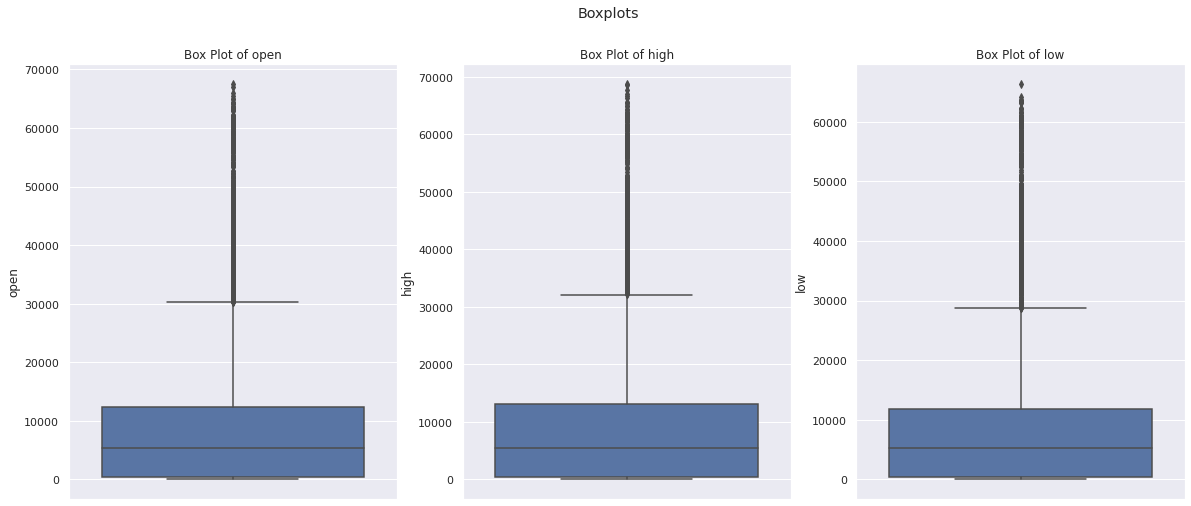

In [ ]:
# Checking for Outliers

fig, ax = plt.subplots(1,3, figsize=(20,8))
fig.suptitle('Boxplots')
sns.boxplot(data=df, y = "open", ax=ax[0])
ax[0].set_title('Box Plot of open')
sns.boxplot(data=df, y = "high", ax=ax[1])
ax[1].set_title('Box Plot of high')
sns.boxplot(data=df, y = "low", ax=ax[2])
ax[2].set_title('Box Plot of low')

plt.show()

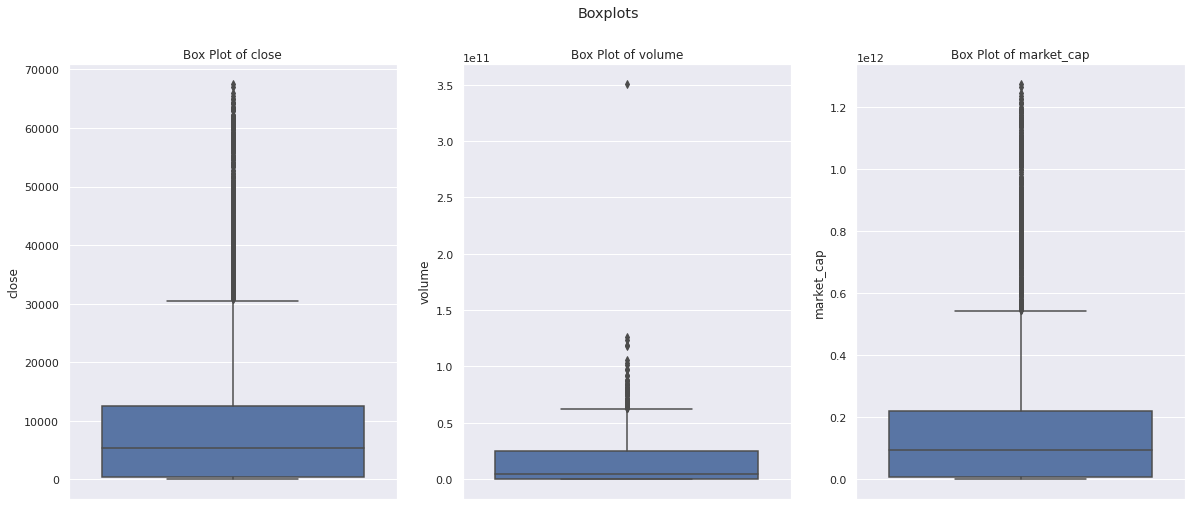

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(20,8))
fig.suptitle('Boxplots')
sns.boxplot(data=df, y = "close", ax=ax[0])
ax[0].set_title('Box Plot of close')
sns.boxplot(data=df, y = "volume", ax=ax[1])
ax[1].set_title('Box Plot of volume')
sns.boxplot(data=df, y = "market_cap", ax=ax[2])
ax[2].set_title('Box Plot of market_cap')

plt.show()

# **Univariate Analysis**

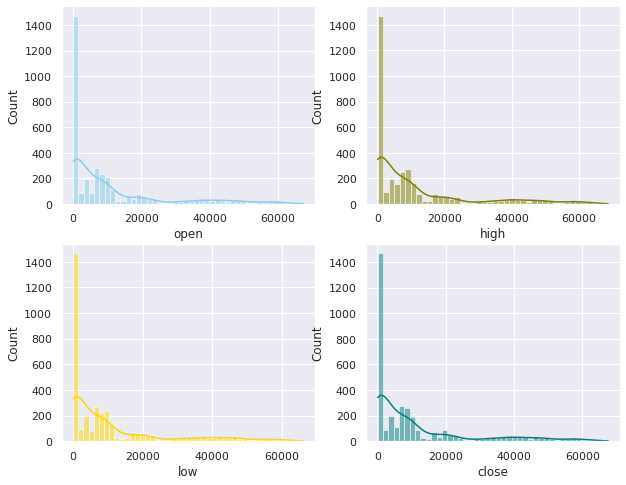

In [ ]:
# set a grey background (use sns.set_theme() if seaborn version 0.11.0 or above)
sns.set(style="darkgrid")

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(data=df, x="open", kde=True, color="skyblue", ax=axs[0, 0])
sns.histplot(data=df, x="high", kde=True, color="olive", ax=axs[0, 1])
sns.histplot(data=df, x="low", kde=True, color="gold", ax=axs[1, 0])
sns.histplot(data=df, x="close", kde=True, color="teal", ax=axs[1, 1])

plt.show()

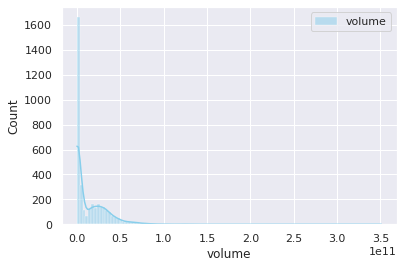

In [ ]:
sns.histplot(data=df, x="volume", color="skyblue", label="volume", kde=True)

plt.legend()
plt.show()

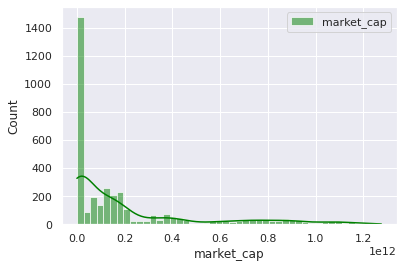

In [ ]:
#histogram for market cap
sns.histplot(data=df, x="market_cap", color="green", label="market_cap", kde=True)

plt.legend()
plt.show()

# **Bivariate analysis**

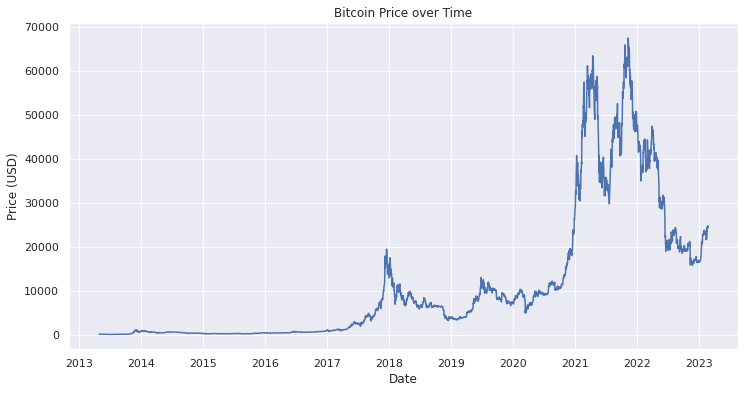

In [ ]:
# Plot the Bitcoin price over time
# Set the figure size
plt.figure(figsize=(12, 6))

plt.plot(df['timestamp'], df['close'])
plt.title('Bitcoin Price over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()


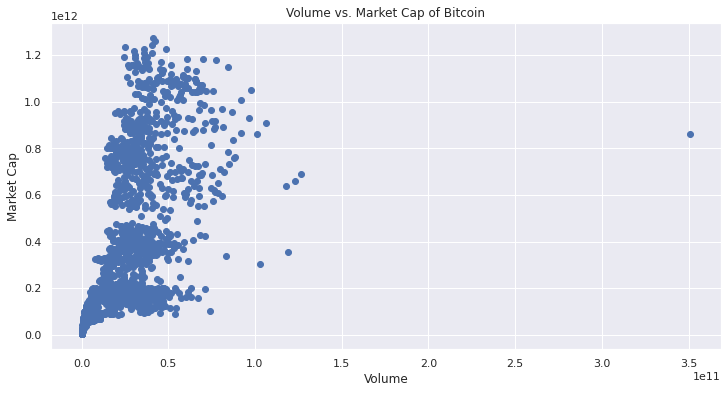

In [ ]:
# Plot scatter the volume of Bitcon data
plt.figure(figsize=(12, 6))

plt.scatter(df['volume'], df['market_cap'])
plt.title('Volume vs. Market Cap of Bitcoin')
plt.xlabel('Volume')
plt.ylabel('Market Cap')
plt.show()


# **Multivariate Analysis**

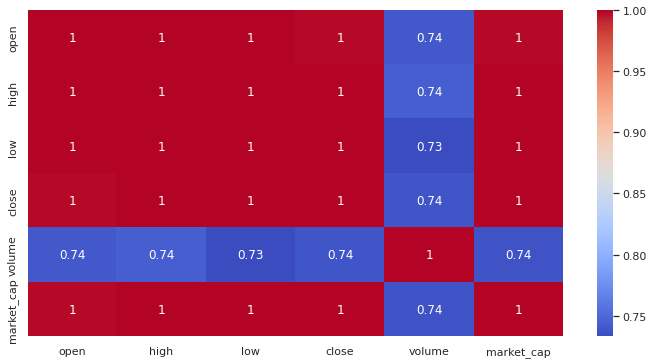

In [ ]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a heatmap of the correlation matrix
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

# Show the plot

plt.show()



In [ ]:
df['Year'] = df.timestamp.dt.year
df['Month'] = df.timestamp.dt.month
df['Day'] = df.timestamp.dt.day

In [ ]:
df.head()

,open,high,low,close,volume,market_cap,timestamp,Year,Month,Day
0,134.444000,147.488007,134.000000,144.539993,0.0,1.603769e+09,2013-04-29 23:59:59.999,2013,4,29
1,144.000000,146.929993,134.050003,139.000000,0.0,1.542813e+09,2013-04-30 23:59:59.999,2013,4,30
2,139.000000,139.889999,107.720001,116.989998,0.0,1.298955e+09,2013-05-01 23:59:59.999,2013,5,1
3,116.379997,125.599998,92.281898,105.209999,0.0,1.168517e+09,2013-05-02 23:59:59.999,2013,5,2
4,106.250000,108.127998,79.099998,97.750000,0.0,1.085995e+09,2013-05-03 23:59:59.999,2013,5,3


In [ ]:
#drop now the timestamp column
df.drop(['timestamp'],axis = 1,inplace = True)
df.head(10)

,open,high,low,close,volume,market_cap,Year,Month,Day
0,134.444000,147.488007,134.000000,144.539993,0.0,1.603769e+09,2013,4,29
1,144.000000,146.929993,134.050003,139.000000,0.0,1.542813e+09,2013,4,30
2,139.000000,139.889999,107.720001,116.989998,0.0,1.298955e+09,2013,5,1
3,116.379997,125.599998,92.281898,105.209999,0.0,1.168517e+09,2013,5,2
4,106.250000,108.127998,79.099998,97.750000,0.0,1.085995e+09,2013,5,3
5,98.099998,115.000000,92.500000,112.500000,0.0,1.250317e+09,2013,5,4
6,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013,5,5
7,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013,5,6
8,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013,5,7
9,109.599998,115.779999,109.599998,113.566002,0.0,1.264049e+09,2013,5,8


In [ ]:
#Get the oldest year and the earliest year
print('Oldest year: ' + str(df['Year'].min()))
print('Earliest year: ' + str(df['Year'].max()))

Oldest year: 2013
Earliest year: 2023


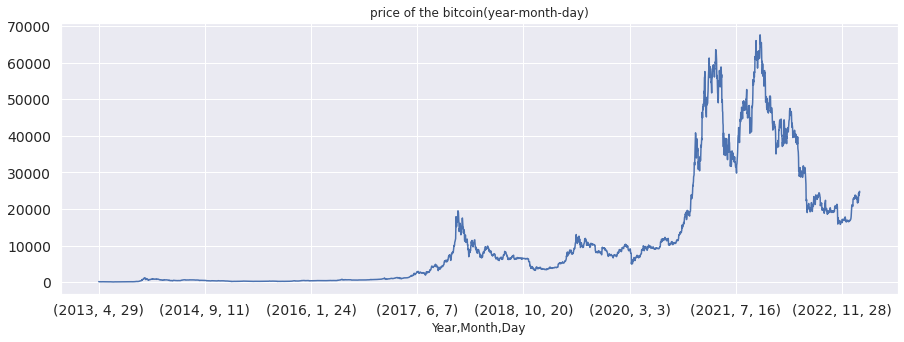

In [ ]:
#get the trend of the price by year month and date
close=df.groupby(['Year','Month','Day'])['close'].mean()
close.plot(figsize=(15,5), title= 'price of the bitcoin(year-month-day)', fontsize=14)

# **Split the data into training and testing sets**

The target is defined as the "close" column, and the features are the remaining columns after dropping the "close" column from the dataframe. We then split the data into training and test sets using train_test_split from the sklearn.model_selection module. The data is split into 80% training data (X_train, y_train) and 20% test data (X_test, y_test)

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into features (X) and target (y)
X = df.drop('close',axis=1).values
y = df['close'].values

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train = np.asarray(X_train).astype(np.float32)
y_train = np.asarray(y_train).astype(np.float32)

# **Build the LSTM model to predict whether the price will fall or rise**

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Initialize the model
model = Sequential()

# Add the first LSTM layer
model.add(LSTM(units=32,activation='Softmax', return_sequences=True, input_shape=(X_train.shape[1], 1)))
#I think that more units (greater dimension of hidden states) will help the network to remember more complex patterns.

# Add additional LSTM layers
model.add(LSTM(units=32,activation='Softmax'))

# Add a fully connected layer
model.add(Dense(1))

# Train the model

We now define two custom loss functions in Keras, using the TensorFlow backend (K).

"mean_squared_error": It calculates the mean of the squared differences between the true values (y_true) and the predicted values (y_pred) along the last axis (-1).

"mean_absolute_error": It calculates the mean of the absolute differences between the true values (y_true) and the predicted values (y_pred) along the last axis (-1).

In [ ]:
from keras import backend as K

def mean_squared_error(y_true, y_pred):
    return K.mean(K.square(y_pred - y_true), axis=-1)

def mean_absolute_error(y_true, y_pred):
    return K.mean(K.abs(y_pred - y_true), axis=-1)

# **compiling and fitting a neural network model in Keras.**

"model.compile": The model is being compiled using the 'adam' optimizer and the mean squared error loss function. Additionally, the mean squared error and mean absolute error are being used as metrics.

**"EarlyStopping"**: An EarlyStopping callback is being set with the following parameters:

**monitor**: The validation loss will be monitored.

**patience**: The training will stop after 10 epochs without improvement in the validation loss.

**mode**: The minimum validation loss will be used to determine improvement.

**"model.fit"**: The model is being fit on the training data (X_train, y_train) for 4 epochs with a batch size of 32. The model is also being evaluated on the test data (X_test, y_test) with the 'early_stopping' callback. The training history is being stored in the 'history' variable.

In [ ]:
# Compile the model
import tensorflow as tf
model.compile(optimizer='adam', loss='mean_squared_error', metrics=[ mean_squared_error,mean_absolute_error])

from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, mode='min')

history = model.fit(X_train, y_train, epochs=4, batch_size=32,
                    validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/4
90/90 [==============================] - 6s 19ms/step - loss: 76959232.0000 - mean_squared_error: 76959232.0000 - mean_absolute_error: 4943.4170 - val_loss: 1529995904.0000 - val_mean_squared_error: 1529995904.0000 - val_mean_absolute_error: 36370.6094
Epoch 2/4
90/90 [==============================] - 1s 13ms/step - loss: 76957808.0000 - mean_squared_error: 76957808.0000 - mean_absolute_error: 4943.2705 - val_loss: 1529985024.0000 - val_mean_squared_error: 1529985024.0000 - val_mean_absolute_error: 36370.4609
Epoch 3/4
90/90 [==============================] - 1s 14ms/step - loss: 76956312.0000 - mean_squared_error: 76956312.0000 - mean_absolute_error: 4943.1216 - val_loss: 1529973504.0000 - val_mean_squared_error: 1529973504.0000 - val_mean_absolute_error: 36370.3086
Epoch 4/4
90/90 [==============================] - 1s 14ms/step - loss: 76954632.0000 - mean_squared_error: 76954632.0000 - mean_absolute_error: 4942.9531 - val_loss: 1529960064.0000 - val_mean_squared_error: 15

# **Evaluate the model**

In [ ]:
# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)

In [ ]:
# get the range of values in the column
min_value = df['close'].min()
max_value = df['close'].max()
value_range = max_value - min_value

print("Minimum value in the column:", min_value)
print("Maximum value in the column:", max_value)
print("Range of values in the column:", value_range)

Minimum value in the column: 68.43099975585938
Maximum value in the column: 67566.8300878775
Range of values in the column: 67498.39908812165


Now we are printing the mean squared error (MSE) and mean absolute error (MAE) metrics.

In [ ]:
scores = model.evaluate(X_test, y_test, verbose=0)
print("MSE: ", scores[1])
print("MAE: ", scores[2])

MSE:  1529960064.0
MAE:  36370.12109375


The range of the target column values is 1.0


The low MSE and MAE values we mentioned in our results (0.00041434180457144976 and 0.014810100197792053, respectively) indicate that our model is making relatively accurate predictions.

In general, lower MSE and MAE values are better, as they indicate that the differences between the true values and the predicted values are smaller.


In [ ]:
# Use the model to make predictions on the test data
test_predictions = model.predict(X_test)

23/23 [==============================] - 0s 4ms/step



# **Visualize the model performance**
**Training Loss vs. Validation Loss:**

This plot shows the training loss and validation loss over the epochs. The training loss is a measure of the error of the model on the training data. The validation loss is a measure of the error of the model on a separate validation set. Ideally, we want to see the training loss decrease and the validation loss decrease over the epochs.


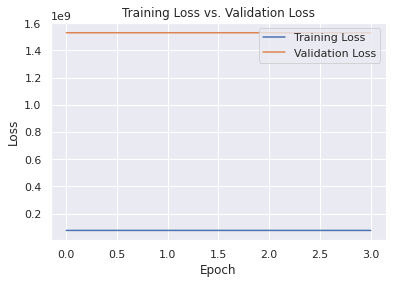

In [ ]:
import matplotlib.pyplot as plt

# Plot the training loss and validation loss over the epochs
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training Loss vs. Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training Loss', 'Validation Loss'], loc='upper right')
plt.show()

From the graph we can tell that we are overfitting since the training loss continues to decrease but the validation loss does not.


# **Error Distribution**

This plot shows the distribution of the errors (actual - predicted). The errors should be close to a normal distribution. If there are outliers or skewness in the distribution, then it indicates that the model is not performing well


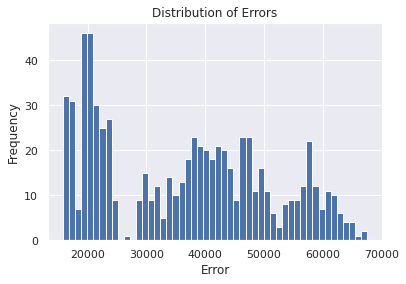

In [ ]:
# Calculate the errors (actual - predicted)
errors = y_test - test_predictions.flatten()

# Plot the distribution of the errors
plt.hist(errors, bins=50)
plt.title('Distribution of Errors')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()

Our distribution is skewed to the right and not close to the normal distribution so we presume that our model isnt perfroming well.For us to solve this we do hyperparameter tuning.

# **Hyperparameter tuning**

We will use Random search instead of  grid search where it samples random combinations of values. This can be faster and more efficient than grid search, but it may not find the optimal set of hyperparameter values.

In [ ]:
X_train.shape

(2868, 8)

In [ ]:
 #If We will be feeding data 1 character at a time your input shape should be (5,1)
 # since your input has 5 timesteps, 1 character each. we will need to reshape your x_train from (2864, 5) to (2864, 5,1)
X_train=X_train.reshape(X_train.shape[0],X_train.shape[1],1)

In [ ]:
from keras.layers.regularization.dropout import Dropout
#This code uses the KerasRegressor wrapper from the scikit-learn library to
#create a Keras model that can be used with scikit-learn's RandomizedSearchCV function.
#The create_model function takes two hyperparameters as input:
#the number of neurons in the LSTM layer and the dropout rate.
#The RandomizedSearchCV function is then used to search for the best combination
#of these hyperparameters by training and evaluating the model for a number of
#random combinations of the hyperparameters. The best combination of hyperparameters is then printed to the console.

from keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import RandomizedSearchCV

# Define the model

def create_model(neurons=1, dropout_rate=0.0):
    model = Sequential()
    model.add(LSTM(neurons, input_shape=(5,1)))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

# Create the model
model = KerasRegressor(build_fn=create_model)

# Define the hyperparameter search space
neurons = [1, 5, 10, 50, 100]
dropout_rate = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
param_grid = dict(neurons=neurons, dropout_rate=dropout_rate)

# Search for the best hyperparameters
random_search = RandomizedSearchCV(model, param_grid, n_iter=10, cv=3, verbose=1)
random_search_result = random_search.fit(X_train, y_train)

# Print the best hyperparameters
print("Best: %f using %s" % (random_search_result.best_score_, random_search_result.best_params_))

<ipython-input-143-dba1ccbd5f81>:24: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  model = KerasRegressor(build_fn=create_model)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.8/dist-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
30 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.8/dist-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.8/dist-packages/keras/wrappers/scikit_learn.py", line 175, in fit
    history = self.model.fit(x, y, **fit_args)
  File "/usr/local/lib/python3.8/dist-packages/keras/utils/traceback_utils.py", line 70, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "/tmp/__auto

ValueError: ignored

Using 100 nuerons and dropout rate of 0.5 will give us a the best score for our model

In [ ]:
# Define the model

def create_model(neurons=100, dropout_rate=0.5):
    model1 = Sequential()
    model1.add(LSTM(neurons, input_shape=(5,1)))
    model1.add(Dropout(dropout_rate))
    model1.add(Dense(1))
    model1.compile(loss='mean_squared_error', optimizer='adam')
    return model1

# Create the model
model1 = KerasRegressor(build_fn=create_model)


# **Regularization**
# Dropout layers - Regularization

Regularization is a technique used to prevent overfitting in deep learning models. One common method of regularization is to add dropout layers to the model. Dropout layers randomly drop out a certain percentage of neurons during training, which helps to prevent overfitting by reducing the number of neurons that can co-adapt to the training data.


In [ ]:
from keras.layers import Dropout

model1 = Sequential()
model1.add(LSTM(100, input_shape=(5,1), return_sequences=True))
model1.add(Dropout(0.5))
model1.add(LSTM(100, return_sequences=True))
model1.add(Dropout(0.5))
model1.add(LSTM(100))
model1.add(Dropout(0.5))
model1.add(Dense(1))

we added dropout layers after the first two LSTM layers and before the final dense layer. The dropout rate is set to 0.5, meaning that 50% of neurons will be randomly dropped out during training.

# **Predicting 30 days in to the future**

In [ ]:
pip install pycaret

In [ ]:
pip install markupsafe==2.0.1

In [ ]:
pip install jinja2

In [ ]:

#make a copy of df
df1 = df.copy()

In [ ]:
df1

In [ ]:
#A variable for predicting 30 days out in the future
future_days = 30

In [ ]:
#create a new column(the target variable) shited "n" units up in this case n = 30
df1['future_price'] = df1[['close']].shift(future_days)
#choose columns to keep
df1= df1[['close','future_price']]
#show the data
df1

In [ ]:
#create the indepentent dataset
x= np.array(df1[df1.columns])
#remove the last n rows from the data when n = 30days
x = x[:len(df1)-future_days]
#create the depentdent dataset y and convert to numpy
y = np.array(df1['future_price'])
#get all the y values except for the last n rows
y = y[:-future_days]
#split the data into 80% training set and 20% test set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

In [ ]:
#get the train data and transform it to a dataframe
train_data = pd.DataFrame(x_train, columns = df1.columns)
#show the first 7 rows of the data
train_data.head(7)

In [ ]:
#get the train data and transform it to a dataframe
test_data = pd.DataFrame(x_test, columns = df1.columns)
#show the first 7 rows of the data
test_data.head(7)